**Welcome to Programming Assignment 5 on Deep Learning for Computer Vision.**



#### **Instructions**
1. Run this notebook in Google Colab with Python 3.x.
2. Write your code only in between the lines 'YOUR CODE STARTS HERE' and 'YOUR CODE ENDS HERE'. You should not change anything else in the code cells. If you do, the answers you are supposed to get at the end of this assignment might be wrong.
3. Run the notebook once, from top to bottom, on a fresh runtime. Do not re-run individual cells out of order.
4. Read documentation of each function carefully.
5. Every question asks for the closest option, so small differences from your hardware or PyTorch build are expected.
6. All the Best!

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import argparse
import pickle
import os
from PIL import Image
import torchvision.models as models
import torch.nn.functional as F
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import torchvision
import random
from tqdm import tqdm
from torch.utils.data import random_split
from torch.autograd import Variable
import cv2
import torchvision.utils as utils
## Please DONOT remove these lines.
# Set random seed for reproducibility.
# The seed is set again at the start of the Multi-Head Attention and ViT sections,
# so that each section is independent of the ones before it.
torch.manual_seed(2024)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(2024)

#AUTO-ENCODERS

In [22]:
### YOUR CODE STARTS HERE ###

# Set device to cuda
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the MNIST training split, downloading it into './data', and apply the transform below.
# Wrap it in a DataLoader with batch size 128 and shuffling enabled.
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root = './data', transform=transform, download=True)
train_loader = DataLoader(train_dataset, shuffle=True, batch_size= 128)

### YOUR CODE ENDS HERE ###

In [23]:
# Define the Autoencoder architecture
class Autoencoder(nn.Module):

    def __init__(self):
        super(Autoencoder, self).__init__()
       ### YOUR CODE STARTS HERE ###

        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128), # Linear layer with input = total number of pixels in a MNIST image sample, output = 128
            nn.ReLU(), # Relu activation
            nn.Linear(128, 64),  #Linear layer with input = 128, output = 64
            nn.ReLU(), # Relu activation
            nn.Linear(64, 32),  #Linear layer with input = 64, output = 32
            nn.ReLU(), # Relu activation
            nn.Linear(32,16) # Linear layer with input = 32, output = 16
        )
        self.decoder = nn.Sequential(
            nn.Linear(16,32), # Linear layer  with input = 16, output = 32
            nn.ReLU(),  # Relu activation
            nn.Linear(32,64), # Linear layer  with input = 32, output = 64
            nn.ReLU(),  # Relu activation
            nn.Linear(64,128), # Linear layer  with input = 64, output = 128
            nn.ReLU(),  # Relu activation
            nn.Linear(128, 28*28), # Linear layer with input = 128 and output = total number of pixels in a MNIST image sample
            nn.Sigmoid()  # Sigmoid activation
        )
    ### YOUR CODE ENDS HERE ###
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [25]:
# Initialize the model, loss function, and optimizer

### YOUR CODE STARTS HERE ###

model = Autoencoder().to(device) # send autoencoders to GPU
criterion = nn.MSELoss()  # Initialize MSE loss, leaving its reduction at the default
optimizer = optim.Adam(params=model.parameters())  # Set Adam as optimizer over this model's parameters, at its default learning rate

# Training loop
num_epochs = 10
for epoch in range(num_epochs):
    for data in train_loader:
        img, _ = data
        img = img.view(img.size(0), -1).to(device)

        # Forward pass
        output = model(img)
        loss = criterion(output, img) # Calculate the loss between the reconstruction and the flattened input

        # Backward pass and optimize
        optimizer.zero_grad()  # Reset Gradient
        loss.backward()
        optimizer.step()
### YOUR CODE ENDS HERE ###
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [1/10], Loss: 0.0456
Epoch [2/10], Loss: 0.0384
Epoch [3/10], Loss: 0.0290
Epoch [4/10], Loss: 0.0312
Epoch [5/10], Loss: 0.0281
Epoch [6/10], Loss: 0.0268
Epoch [7/10], Loss: 0.0257
Epoch [8/10], Loss: 0.0231
Epoch [9/10], Loss: 0.0231
Epoch [10/10], Loss: 0.0218


In [26]:
# Function to visualize original and reconstructed images

def visualize_reconstruction(model, data_loader, num_images=5):
    model.eval()
    with torch.no_grad():
        for img, _ in data_loader:
            img = img.view(img.size(0), -1).to(device)
            output = model(img)

            fig, axes = plt.subplots(2, num_images, figsize=(12, 4))
            for i in range(num_images):
                axes[0, i].imshow(img[i].cpu().view(28, 28), cmap='gray')
                axes[0, i].axis('off')
                axes[1, i].imshow(output[i].cpu().view(28, 28), cmap='gray')
                axes[1, i].axis('off')

            plt.tight_layout()
            plt.show()
            break

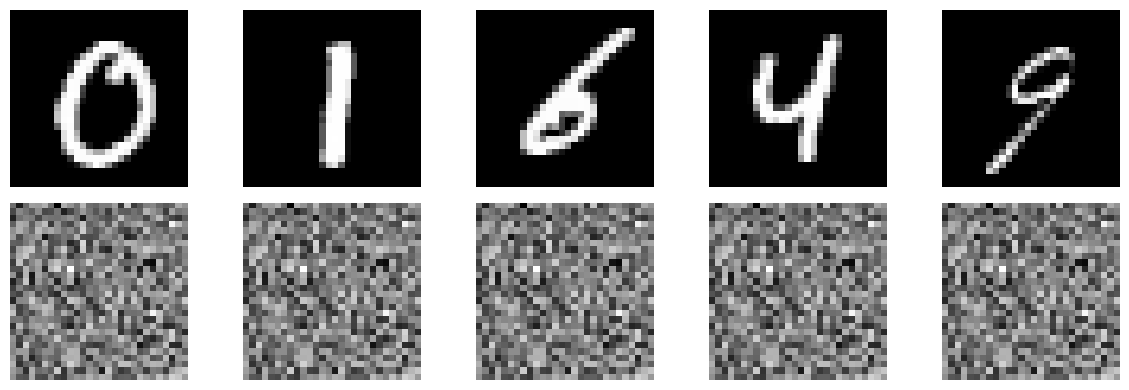

In [21]:

# Visualize some reconstructions
visualize_reconstruction(model, DataLoader(train_dataset, batch_size=32, shuffle=True))

## Question 1: Auto-Encoder

What is the loss value printed at the end of the 10th epoch? (choose the closest option)

1.   0.0559
2.   0.0212
3.   0.2321
4.   0.9452

In [30]:
#Define an overcomplete auto-encoder architechture

class OvercompleteAutoencoder(nn.Module):
  ### YOUR CODE STARTS HERE ###
    def __init__(self):
        super(OvercompleteAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 512),  # Linear layer for increasing dimensionality (28*28 to 512)
            nn.ReLU(),  #Relu activation
            nn.Linear(512,1024),   # Linear layer for Further increase to 1024
            nn.ReLU(),  #Relu activation
            nn.Linear(1024, 2048)  # Overcomplete representation of dimention 2048
        )
        self.decoder = nn.Sequential(
            nn.Linear(2048, 1024),  # Linear layer from 2048 to 1024
            nn.ReLU(), #Relu activation
            nn.Linear(1024, 512), # Linear layer from 1024 to 512
            nn.ReLU(),#Relu activation
            nn.Linear(512, 28*28), # Linear layer from 512 to 28*28
            nn.Sigmoid()  #Sigmoid
        )
  ### YOUR CODE ENDS HERE ###
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [32]:
over_com_model = OvercompleteAutoencoder().to(device)

## Please DONOT remove this line.
## This model is trained with its own optimizer, over its own parameters.
over_com_optimizer = optim.Adam(over_com_model.parameters())

### YOUR CODE STARTS HERE ###

# Training loop
num_epochs = 10
for epoch in range(num_epochs):
    for data in train_loader:
        img, _ = data
        img = img.view(img.size(0), -1).to(device)

        # Forward pass
        output = over_com_model(img)
        loss = criterion(output, img)   # calculate loss using the criterion defined earlier

        # Backward pass and optimize
        over_com_optimizer.zero_grad()  # Reset the gradients in over_com_optimizer
        loss.backward()   # Backward pass
        over_com_optimizer.step()   # Update the parameters using over_com_optimizer
### YOUR CODE ENDS HERE ###
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [1/10], Loss: 0.0216
Epoch [2/10], Loss: 0.0123
Epoch [3/10], Loss: 0.0092
Epoch [4/10], Loss: 0.0078
Epoch [5/10], Loss: 0.0066
Epoch [6/10], Loss: 0.0062
Epoch [7/10], Loss: 0.0060
Epoch [8/10], Loss: 0.0055
Epoch [9/10], Loss: 0.0051
Epoch [10/10], Loss: 0.0050


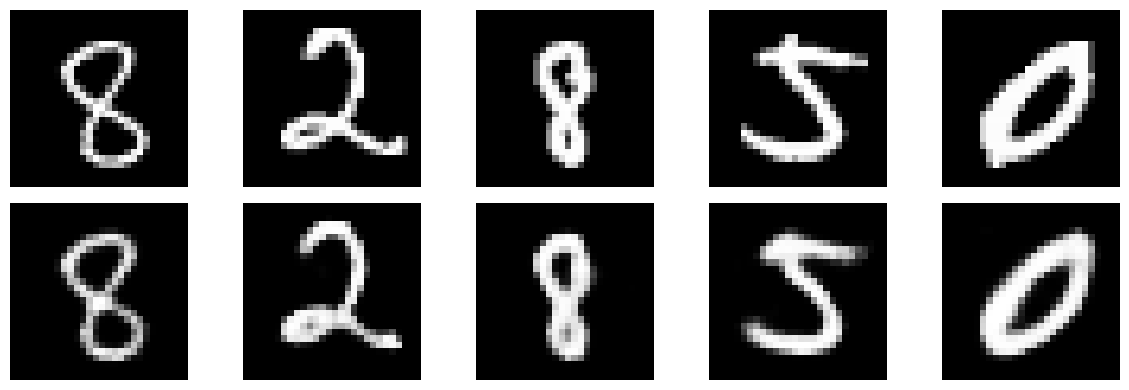

In [33]:
visualize_reconstruction(over_com_model, DataLoader(train_dataset, batch_size=32, shuffle=True))

## Question 2: Overcomplete Auto-Encoder

What is the loss value printed at the end of the 10th epoch? (choose the closest option)

1.   0.0052
2.   0.0509
3.   0.2320
4.   0.0019

#Multi Head Attention

In [34]:
## Please DO NOT change these values.
#This is the config that will be used for implementing the Multi-head attention
config = {
    'QI_DIM': 64,
    'VI_DIM': 64,
    'KI_DIM': 64,
    'QO_DIM': 32,
    'VO_DIM': 32,
    'OP_DIM': 32,
    'NUM_HEADS': 8,
}

In [35]:
#A class for implementing the Multi-head Attention
class MultiHeadAttention(nn.Module):

    def __init__(self, config):
        super(MultiHeadAttention, self).__init__()

        ### YOUR CODE STARTS HERE ###

        #set the op dimension, number of heads based on the value given in config
        self.op_dim = config['OP_DIM']
        self.n_heads = config['NUM_HEADS']

        #set the query dimension as QO_DIM from the config and value dimension as VO_DIM
        self.query_dim = config['QO_DIM']
        self.value_dim = config['VO_DIM']

        #set the respective dimensions
        #note that the key transform must project to the query output dimension,
        #so that Q and K can later be multiplied together
        self.QTrans = nn.Linear(config['QI_DIM'], config['QO_DIM'])
        self.KTrans = nn.Linear(config['KI_DIM'], config['QO_DIM'])
        self.VTrans = nn.Linear(config['VI_DIM'], config['VO_DIM'])
        self.OTrans = nn.Linear(config['VO_DIM'], config['OP_DIM'])

        #set the scaling factor as follows:
        #scale = sqrt(QO_DIM/NUM_HEADS)
        self.scale = torch.sqrt(torch.FloatTensor([self.query_dim // self.n_heads]))

        ### YOUR CODE ENDS HERE ###



    def forward(self, q_inp, k_inp, v_inp, ret_atn=False):

        #making sure that shapes are similar across dim=0
        assert q_inp.shape[0] == k_inp.shape[0]

        #setting batch size
        batch_size = q_inp.shape[0]
        seq_length = q_inp.shape[1]

        ### YOUR CODE STARTS HERE ###
        #pass q_inp, k_inp, v_inp through the linear layers defined in the
        #init function

        Q = self.QTrans(q_inp)
        K = self.KTrans(k_inp)
        V = self.VTrans(v_inp)

        #reshape the Q, K, V tensors to (batch_size, num_heads, seq_length, head_dim), by first
        #splitting the last dimension across the heads and then swapping the head and sequence axes
        #hint: you can do this with view() and permute() of pytorch
        head_dim_q = self.query_dim // self.n_heads
        head_dim_v = self.value_dim // self.n_heads

        Q = Q.view(batch_size, -1, self.n_heads, head_dim_q).permute(0, 2, 1, 3)
        K = K.view(batch_size, -1, self.n_heads, head_dim_q).permute(0, 2, 1, 3)
        V = V.view(batch_size, -1, self.n_heads, head_dim_v).permute(0, 2, 1, 3)


        # define energy as matrix product of Q and K divided by self.scale value
        #hint: use torch.matmul() for this and do not forget to reshape K vector as (batch_size, num_heads, self.query_dim/num_heads, -1)
        #this should be done in order to carry out the matrix multiplication
        energy = torch.matmul(Q, K.transpose(-2, -1)) / self.scale.to(Q.device)

        #define attention as softmax of energy vector across the last dimension
        attention = F.softmax(energy, dim=-1)

        ### YOUR CODE ENDS HERE ###

        #multiplying the attention with value tensor
        attended = torch.matmul(attention, V).permute(0, 2, 1, 3).contiguous()

        #passing the attended tensor through OTrans linear layer
        out = self.OTrans(attended.view(batch_size, seq_length, -1))

        if ret_atn:
            return out, attention

        else:
            return out

In [36]:
## Please DONOT remove these lines.
## The seed is set again here so that this question does not depend on the sections above it.
torch.manual_seed(2024)
q = torch.rand(4, 2, 64)
k = torch.rand(4, 2, 64)
v = torch.rand(4, 2, 64)

### YOUR CODE STARTS HERE ###

#initialise an instance of MultiHeadAttention class, leaving it on the CPU
d = MultiHeadAttention(config)

#pass q, k, v values through the instance, asking it to also return the attention
x, y = d(q, k, v, ret_atn=True)

#print the single largest value in the whole attention tensor and report your answer
print(f"Largest value in attention tensor: {y.max().item():.4f}")

### YOUR CODE ENDS HERE ###

Largest value in attention tensor: 0.5412


## Question 3: MultiHead-Attention

Given a set of query, key, value vectors, calculate the attention values using multihead attention.

Choose the closest option to the maximum value of the attention tensor.

1.   0.2312
2.   0.7851
3.   0.5412
4.   0.9452


# ViT

In [45]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

In [46]:

# Define the Patch Embedding class
class PatchEmbedding(nn.Module):
  ### YOUR CODE STARTS HERE ###
    def __init__(self, img_size=28, patch_size=7, in_channels=1, embed_dim=64):
        super().__init__()  # Initialize the parent class
        self.img_size = img_size  # Size of the input image (28x28 for MNIST)
        self.patch_size = patch_size  # Size of each patch
        self.n_patches = (img_size // patch_size) ** 2  # Number of patches
        # Convolutional layer to create patch embeddings, with kernel size and stride both equal to the patch size
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)  # Apply the convolutional projection to create patch embeddings
        x = x.flatten(2)  # Flatten the spatial dimensions
        x = x.transpose(1, 2)  # Transpose to get (batch_size, n_patches, embed_dim)
        return x
  ### YOUR CODE ENDS HERE ###

In [47]:
# Define the Simple Vision Transformer (ViT) class
class SimpleViT(nn.Module):
    def __init__(self, img_size=28, patch_size=7, in_channels=1, embed_dim=64, num_heads=4, num_layers=2, num_classes=10):
        super().__init__()  # Initialize the parent class
        ### YOUR CODE STARTS HERE ###
        # Create the patch embedding layer, passing through the arguments of this constructor
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        ### YOUR CODE ENDS HERE ###
        # Learnable classification token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # Learnable position embeddings
        self.pos_embed = nn.Parameter(torch.zeros(1, self.patch_embed.n_patches + 1, embed_dim))

        # Create the transformer encoder
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, batch_first=True),
            num_layers=num_layers
        )

        # Final classification layer
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        ### YOUR CODE STARTS HERE ###
        x = self.patch_embed(x)  # Create patch embeddings
        cls_tokens = self.cls_token.expand(x.shape[0], -1, -1)  # Expand cls token to batch size
        x = torch.cat((cls_tokens, x), dim=1)  # Concatenate cls token with patch embeddings, placing it first in the sequence
        x = x + self.pos_embed  # Add positional embeddings

        x = self.transformer(x)  # Pass through the transformer encoder
        x = x[:, 0]  # Extract the cls token output
        x = self.fc(x)  # Pass through the final classification layer
        ### YOUR CODE ENDS HERE ###
        return x

In [48]:
## Please DONOT remove these lines.
## The seed is set again here so that this section does not depend on the sections above it.
torch.manual_seed(2024)
np.random.seed(2024)

### YOUR CODE STARTS HERE ###
# Data preparation
# Define the image transformations
transform = transforms.Compose([
    transforms.ToTensor() ,
    transforms.Normalize((0.1307,), (0.3081,))  # Normalize with MNIST = 0.1307 mean and std = 0.3081
])

# Load the MNIST train dataset into './data' with transform = transform
dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
### YOUR CODE ENDS HERE ###

## Please DONOT modify this block.
# Split the dataset into training and validation sets
train_dataset, val_dataset = random_split(dataset, [55000, 5000])
# Load the test dataset
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128)
test_loader = DataLoader(test_dataset, batch_size=128)

### YOUR CODE STARTS HERE ###
# Initialize model, loss function, and optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')   # Use GPU if available
model = SimpleViT().to(device)   # Create the model with its default arguments and move it to the device
criterion = nn.CrossEntropyLoss()   # Define the loss function
optimizer = optim.Adam(model.parameters(), lr=0.001)   # Define the optimizer with ADAM and learning rate = 0.001

# Training loop
num_epochs = 5  # Number of times to iterate over the entire dataset
train_losses, val_losses = [], []  # Lists to store the losses for plotting

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    train_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)  # Move data to device
        optimizer.zero_grad() # Zero out the gradients
        outputs = model(images)  # Forward pass
        loss = criterion(outputs, labels)  # Compute the loss
        loss.backward()  # Backpropagate the loss
        optimizer.step()  # Update the weights
        train_loss += loss.item()  # Accumulate the loss

    train_loss /= len(train_loader)  # Compute the training loss averaged over the batches
    train_losses.append(train_loss)

    # Validation
    model.eval()  # Set the model to evaluation mode
    val_loss = 0.0
    with torch.no_grad():  # Disable gradient computation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)  # Get output from the model with images as input
            loss = criterion(outputs, labels) # Compute the loss
            val_loss += loss.item() # Accumulate the loss

    val_loss /= len(val_loader)  # Compute the validation loss averaged over the batches
    val_losses.append(val_loss)
    ### YOUR CODE ENDS HERE ###
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

Epoch [1/5], Train Loss: 0.9050, Val Loss: 0.3928
Epoch [2/5], Train Loss: 0.3390, Val Loss: 0.2163
Epoch [3/5], Train Loss: 0.2206, Val Loss: 0.1703
Epoch [4/5], Train Loss: 0.1766, Val Loss: 0.1507
Epoch [5/5], Train Loss: 0.1461, Val Loss: 0.1157


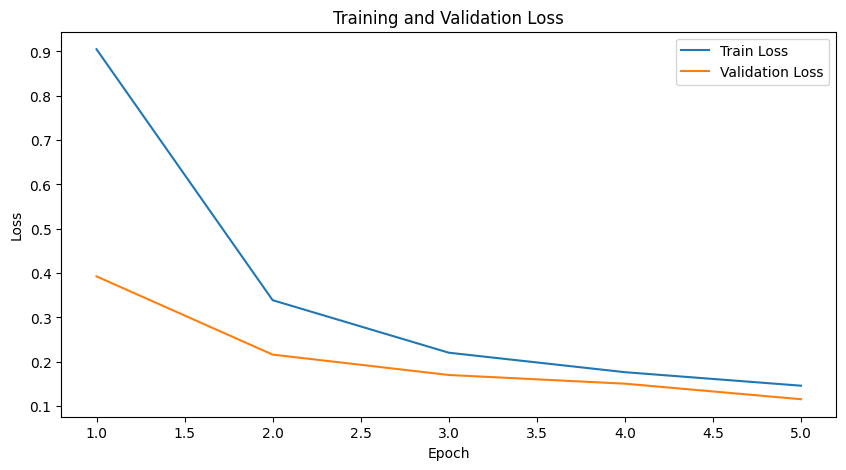

Test Accuracy: 96.80%


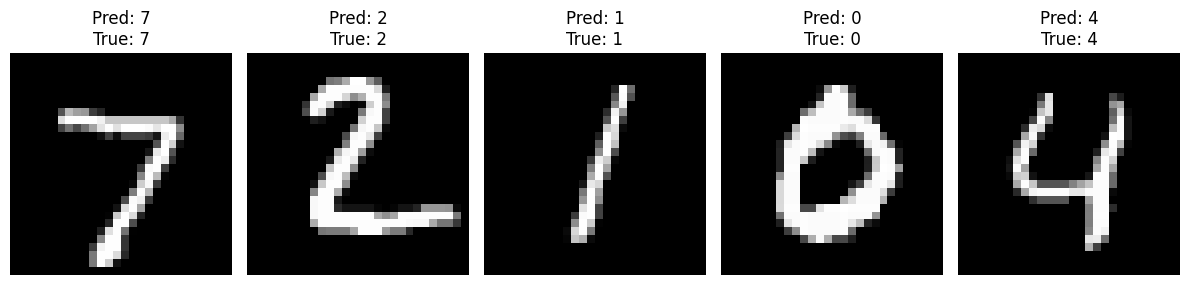

In [49]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

# Test the model on the full MNIST test split
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)  # Get the predicted class
        total += labels.size(0)
        correct += (predicted == labels).sum().item()  # Count correct predictions

accuracy = 100 * correct / total
print(f'Test Accuracy: {accuracy:.2f}%')

# Function to visualize predictions
def visualize_predictions(model, data_loader, num_images=5):
    model.eval()
    images, labels = next(iter(data_loader))  # Get a batch of images
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        outputs = model(images)  # Get output from the model with images as input
        _, predicted = torch.max(outputs, 1)  # Get the predicted classes

    fig, axes = plt.subplots(1, num_images, figsize=(12, 3))
    for i in range(num_images):
        axes[i].imshow(images[i].cpu().squeeze(), cmap='gray')  # Display the image
        axes[i].set_title(f'Pred: {predicted[i]}\nTrue: {labels[i]}')  # Show predicted and true labels
        axes[i].axis('off')  # Turn off axis

    plt.tight_layout()
    plt.show()

# Visualize some predictions
visualize_predictions(model, test_loader)

## Question 4:

Validation loss saturates after how many epochs? Treat the loss as saturated once the drop from one epoch to the next falls below 5% of the previous epoch's validation loss.

1.   1
2.   Does not saturate
3.   2
4.   4

## Question 5:

What is the validation loss printed at the end of the 5th epoch? (choose the closest value)

1.   1.450
2.   0.3441
3.   0.783
4.   0.1157


## Question 6:

What is the test accuracy? (select closest value)

1.   96.80%
2.   50.39%
3.   85.30%
4.   06.69%